# Previsão de Risco à Saúde (Dados Reais Anonimizados)
Registros de pacientes anonimizados com classificação multiclasse de risco à saúde

# Descrição

Este conjunto de dados contém dados de saúde de pacientes reais, cuidadosamente limpos e anonimizados para proteger a privacidade. Ele fornece sinais vitais e parâmetros clínicos de 1.000 pacientes, juntamente com seus respectivos níveis de risco à saúde (Normal, Baixo, Médio, Alto).

O conjunto de dados foi desenvolvido para pesquisas em aprendizado de máquina, ciência de dados e análise de saúde. Ele pode ser usado para construir modelos preditivos que auxiliam profissionais de saúde na detecção precoce de pacientes de alto risco e na tomada de melhores decisões médicas.

Colunas:

Patient_ID – Identificador único e anônimo do paciente.

Frequência respiratória – Respirações por minuto.

Saturação de oxigênio – Nível de saturação de oxigênio (%) no sangue.

O2_Scale – Escala de oxigenoterapia utilizada.

PA sistólica – Pressão arterial sistólica (mmHg).

Frequência cardíaca – Batimentos cardíacos por minuto.

Temperatura – Temperatura corporal (°C).

Consciência – Nível de consciência (A = Alerta, P = Resposta à dor, C = Confusão, V = Verbal, U = Sem resposta).

On_Oxygen – Se o paciente está recebendo oxigênio suplementar (0 = Não, 1 = Sim).

Nível_de_risco – Variável alvo (Normal, Baixo, Médio, Alto).

Possíveis casos de uso:

Desenvolvimento de modelos de aprendizado de máquina para classificação de risco.

Identificar as características mais críticas que afetam os níveis de risco dos pacientes.

Simulações de assistência médica e projetos de pesquisa acadêmica.

Construindo sistemas de suporte à decisão clínica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

df_health = pd.read_csv('Health_Risk_Dataset.csv')

In [2]:
#Informações
df_health.info()
df_health.head()
df_health.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Respiratory_Rate   1000 non-null   int64  
 2   Oxygen_Saturation  1000 non-null   int64  
 3   O2_Scale           1000 non-null   int64  
 4   Systolic_BP        1000 non-null   int64  
 5   Heart_Rate         1000 non-null   int64  
 6   Temperature        1000 non-null   float64
 7   Consciousness      1000 non-null   object 
 8   On_Oxygen          1000 non-null   int64  
 9   Risk_Level         1000 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 78.3+ KB


,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,On_Oxygen
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,21.511000,92.59000,1.124000,106.160000,98.460000,37.921000,0.274000
std,5.287517,4.47302,0.329746,17.897562,19.694626,1.113696,0.446232
min,12.000000,74.00000,1.000000,50.000000,60.000000,35.600000,0.000000
25%,17.000000,90.00000,1.000000,94.000000,84.000000,37.100000,0.000000
50%,20.000000,94.00000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.00000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.00000,2.000000,146.000000,163.000000,41.800000,1.000000


In [3]:
df_health

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25,96,1,97,107,37.5,A,0,Medium
1,P0738,28,92,2,116,151,38.5,P,1,High
2,P0741,29,91,1,79,135,38.4,A,0,High
3,P0661,24,96,1,95,92,37.3,A,0,Medium
4,P0412,20,96,1,97,97,37.4,A,0,Low
...,...,...,...,...,...,...,...,...,...,...
995,P0107,18,96,1,124,72,37.2,A,0,Normal
996,P0271,19,95,1,129,70,38.1,A,0,Low
997,P0861,39,82,1,101,137,37.5,A,1,High
998,P0436,15,92,1,106,108,38.6,A,0,Medium


In [4]:
#Valores ausentes
df_health.isna().sum()

Patient_ID           0
Respiratory_Rate     0
Oxygen_Saturation    0
O2_Scale             0
Systolic_BP          0
Heart_Rate           0
Temperature          0
Consciousness        0
On_Oxygen            0
Risk_Level           0
dtype: int64

In [5]:
#Valores únicos na coluna 'Consciousness'
print("Valores únicos na coluna 'Consciousness':")
print(df_health['Consciousness'].value_counts())

#Valores únicos na coluna 'Risk_Level'
print("Valores únicos na coluna 'Risk_Level':")
print(df_health['Risk_Level'].value_counts())

Valores únicos na coluna 'Consciousness':
Consciousness
A    914
V     33
U     26
P     20
C      7
Name: count, dtype: int64
Valores únicos na coluna 'Risk_Level':
Risk_Level
Medium    306
High      279
Low       255
Normal    160
Name: count, dtype: int64


C:\Users\Usuário\AppData\Local\Temp\ipykernel_12352\3312501706.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_health, x='Risk_Level', order=df_health['Risk_Level'].value_counts().index, palette='rocket')


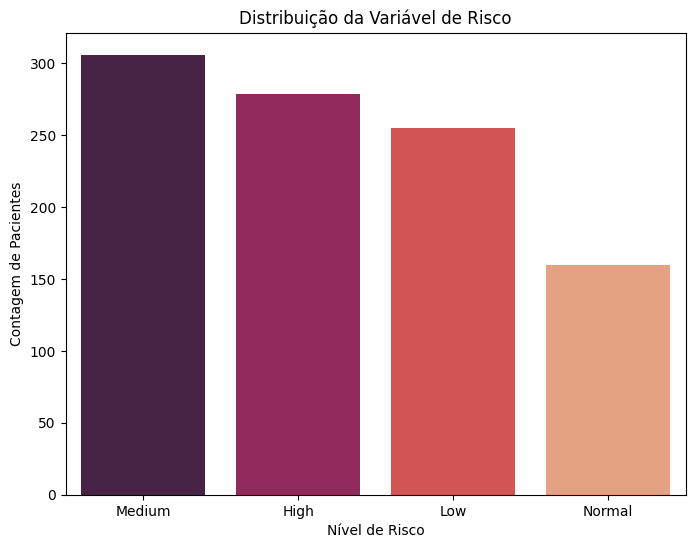

In [6]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_health, x='Risk_Level', order=df_health['Risk_Level'].value_counts().index, palette='rocket')
plt.title('Distribuição da Variável de Risco')
plt.xlabel('Nível de Risco')
plt.ylabel('Contagem de Pacientes')
plt.show()

A maioria dos pacientes se enquadra nas categorias de risco Médio e Alto, enquanto as categorias Baixo e Normal são menos representadas.

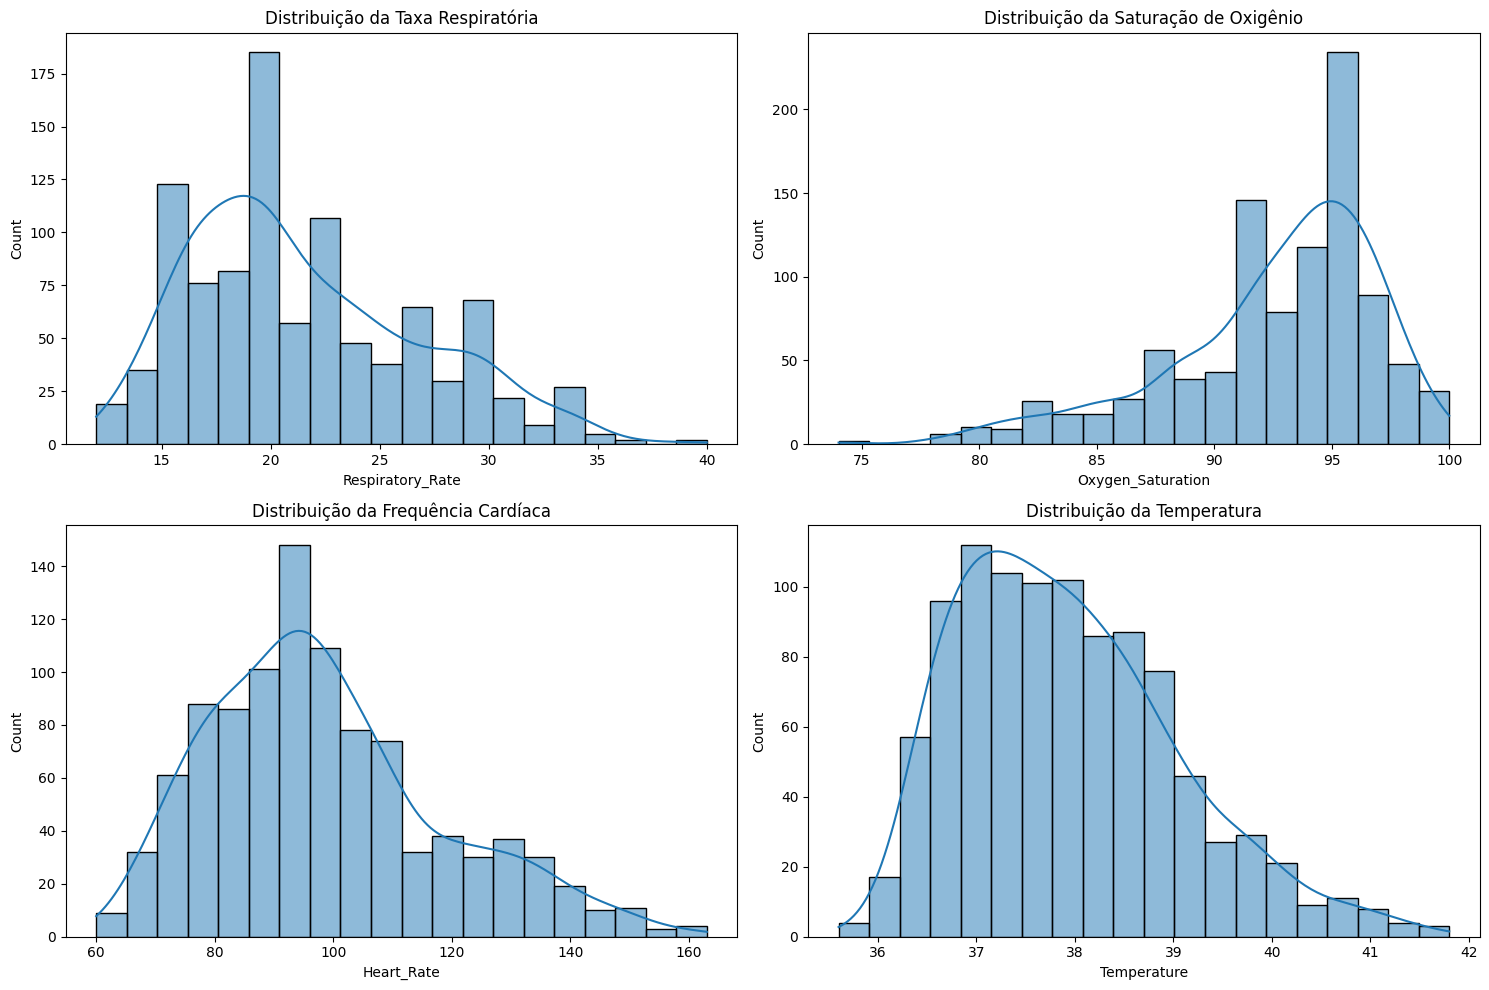

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(df_health['Respiratory_Rate'], bins=20, kde=True, ax=axes[0, 0]).set_title('Distribuição da Taxa Respiratória')
sns.histplot(df_health['Oxygen_Saturation'], bins=20, kde=True, ax=axes[0, 1]).set_title('Distribuição da Saturação de Oxigênio')
sns.histplot(df_health['Heart_Rate'], bins=20, kde=True, ax=axes[1, 0]).set_title('Distribuição da Frequência Cardíaca')
sns.histplot(df_health['Temperature'], bins=20, kde=True, ax=axes[1, 1]).set_title('Distribuição da Temperatura')
plt.tight_layout()
plt.show()

Mostram a distribuição de diferentes variáveis clínicas em uma população de pacientes: Taxa Respiratória, Saturação de Oxigênio, Frequência Cardíaca e Temperatura.

**Respiratória**
Sugere que a população pode ser dividida em dois grupos com padrões respiratórios diferentes. A maioria dos pacientes tem uma taxa respiratória entre 15 e 25.

**Saturação**
O pico principal está em torno de 95%, indicando que a grande maioria dos pacientes tem uma boa saturação de oxigênio. Existem poucos casos com saturação abaixo de 85%.

**Frequência Cardíaca**
O pico de distribuição está entre 90 e 100 batimentos por minuto. Conforme a frequência aumenta, o número de pacientes diminui, com poucos casos acima de 140 batimentos por minuto.

**Temperatura**
O pico de distribuição está entre 37°C e 38°C, que são considerados valores normais. 

C:\Users\Usuário\AppData\Local\Temp\ipykernel_12352\3993172848.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Risk_Level', y='Respiratory_Rate', data=df_health, ax=axes[0, 0], palette='rocket')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_12352\3993172848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Risk_Level', y='Oxygen_Saturation', data=df_health, ax=axes[0, 1], palette='rocket')
C:\Users\Usuário\AppData\Local\Temp\ipykernel_12352\3993172848.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Risk_Level', y=

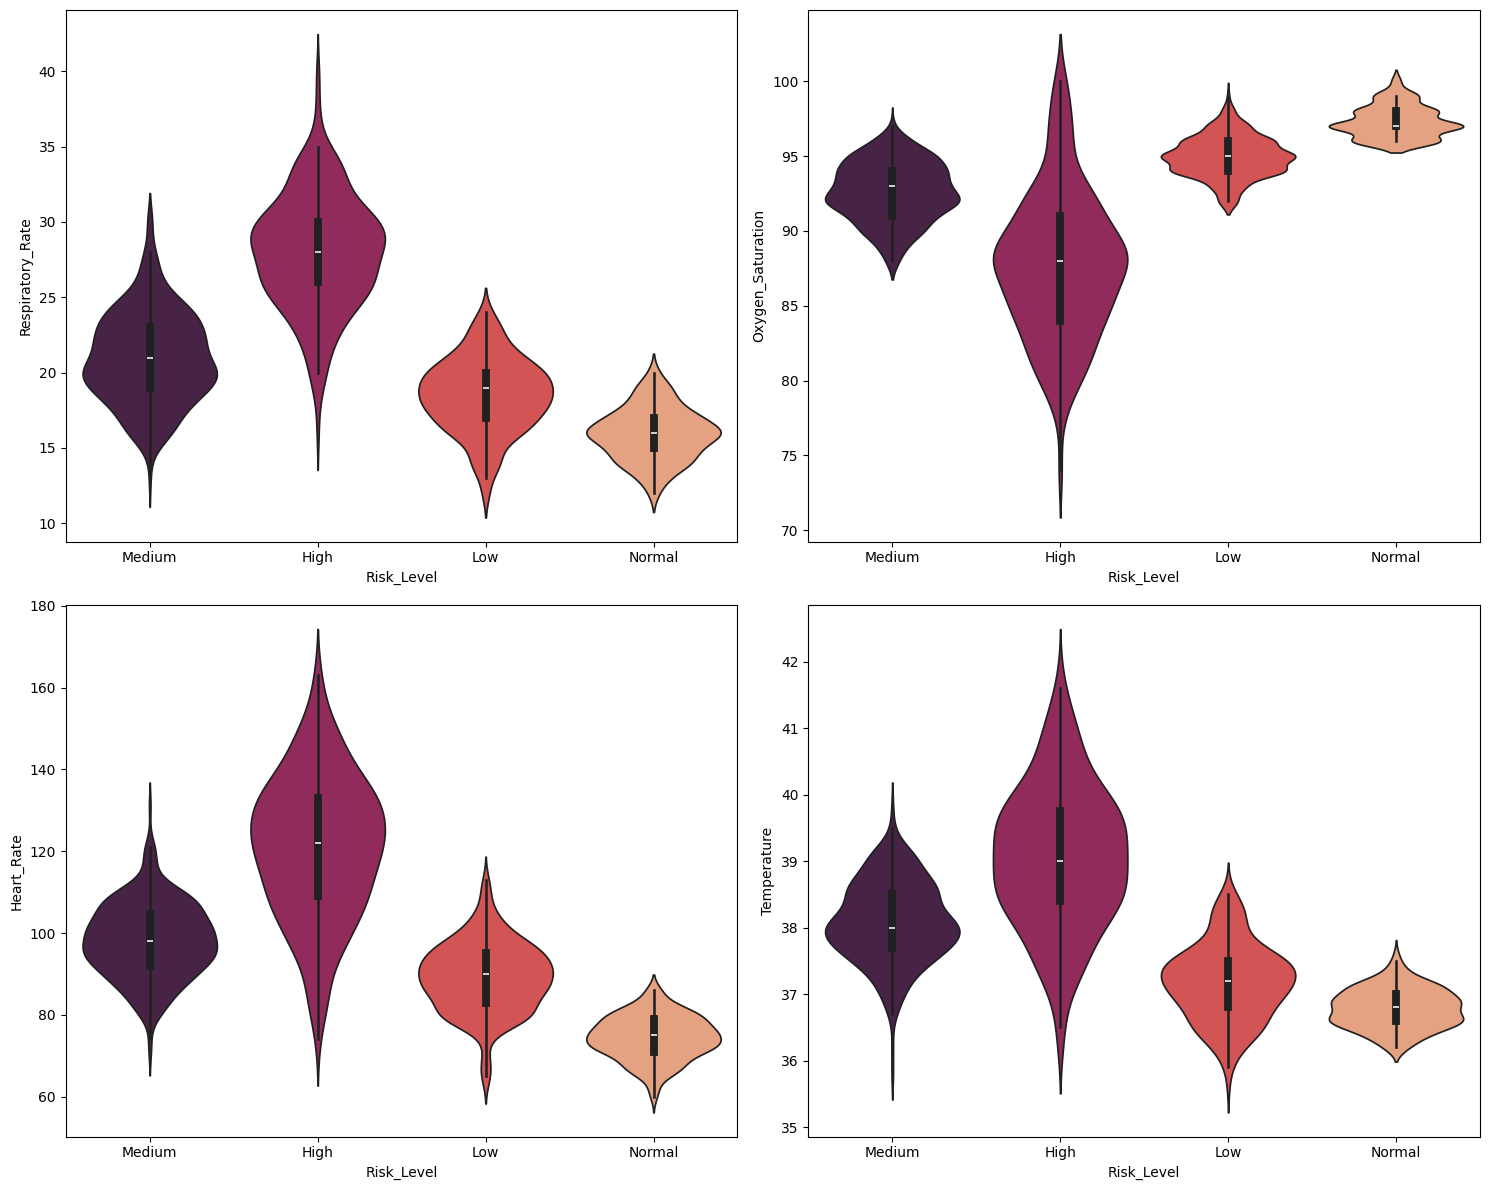

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
sns.violinplot(x='Risk_Level', y='Respiratory_Rate', data=df_health, ax=axes[0, 0], palette='rocket')
sns.violinplot(x='Risk_Level', y='Oxygen_Saturation', data=df_health, ax=axes[0, 1], palette='rocket')
sns.violinplot(x='Risk_Level', y='Heart_Rate', data=df_health, ax=axes[1, 0], palette='rocket')
sns.violinplot(x='Risk_Level', y='Temperature', data=df_health, ax=axes[1, 1], palette='rocket')
plt.tight_layout()
plt.show()

O grupo de risco Alto consistentemente apresenta valores mais elevados e mais variáveis para Taxa Respiratória, Frequência Cardíaca e Temperatura, e valores mais baixos e mais variáveis para Saturação de Oxigênio. Isso sugere que a combinação de padrões clínicos anormais (taquicardia, taquipneia e febre) e baixa saturação de oxigênio é um forte indicador de alto risco.

In [9]:
#Codificar a variável 'Consciousness' (A -> 0, P -> 1)
df_health['Consciousness'] = df_health['Consciousness'].map({'A': 0, 'P': 1})

In [10]:
#Remover a coluna 'Patient_ID'
df_health = df_health.drop('Patient_ID', axis=1)

In [11]:
#Treinamento
le = LabelEncoder()
df_health['Risk_Level_Encoded'] = le.fit_transform(df_health['Risk_Level'])

risk_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapeamento de 'Risk_Level': {risk_mapping}")

X = df_health.drop(['Risk_Level', 'Risk_Level_Encoded'], axis=1)
y = df_health['Risk_Level_Encoded']

print("Divisão dos Dados")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensão dos dados de treino (X_train): {X_train.shape}")
print(f"Dimensão dos dados de teste (X_test): {X_test.shape}")

Mapeamento de 'Risk_Level': {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2), 'Normal': np.int64(3)}
Divisão dos Dados
Dimensão dos dados de treino (X_train): (800, 8)
Dimensão dos dados de teste (X_test): (200, 8)


Relatório de Classificação:
              precision    recall  f1-score   support

        High       1.00      0.96      0.98        56
         Low       0.96      0.92      0.94        51
      Medium       0.91      0.98      0.94        61
      Normal       1.00      0.97      0.98        32

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

Acurácia do modelo: 0.96


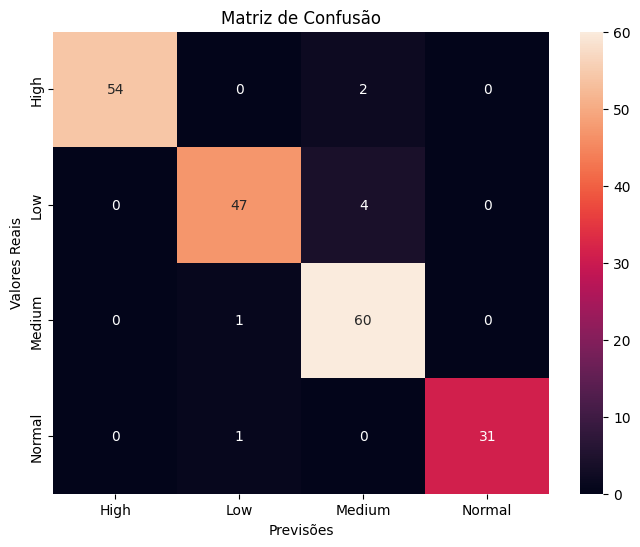

In [12]:
#Modelagem
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.2f}")

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='rocket', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão')
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.show()

Os maiores acertos foram nas classificações de risco Médio e Alto.
As poucas confusões que ocorreram foram principalmente entre categorias adjacentes (ex: Low foi confundido com Medium). O erro mais notável foi classificar 2 casos de risco Médio como Alto, o que, em um contexto clínico, pode ser uma classificação aceitável, pois peca por excesso de cautela. Não houve casos de risco Alto classificados erroneamente como categorias mais baixas, o que é crucial para a segurança do paciente.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_12352\3972917469.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='rocket')


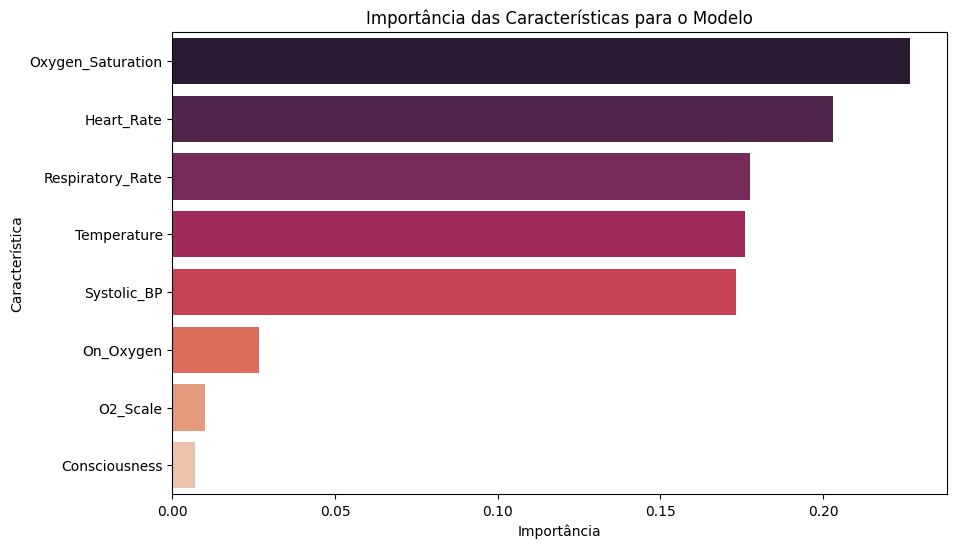

Análise completa concluída.


In [13]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='rocket')
plt.title('Importância das Características para o Modelo')
plt.xlabel('Importância')
plt.ylabel('Característica')
plt.show()

print("Análise completa concluída.")

A classificação prioriza os sinais vitais clássicos (Saturação de Oxigênio, Frequência Cardíaca, Taxa Respiratória, Temperatura e Pressão Sanguínea Sistólica) para determinar o nível de risco. Isso está alinhado com o conhecimento médico, onde esses parâmetros são cruciais para avaliar a gravidade do estado de um paciente. As outras características contribuem pouco para a predição.

In [14]:
from sklearn.preprocessing import OneHotEncoder

#Codificação
categorical_cols = ['Consciousness']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_features = encoder.fit_transform(df_health[categorical_cols])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

df_health = pd.concat([df_health.drop(categorical_cols, axis=1), encoded_df], axis=1)

print(df_health.head())

   Respiratory_Rate  Oxygen_Saturation  O2_Scale  Systolic_BP  Heart_Rate  \
0                25                 96         1           97         107   
1                28                 92         2          116         151   
2                29                 91         1           79         135   
3                24                 96         1           95          92   
4                20                 96         1           97          97   

   Temperature  On_Oxygen Risk_Level  Risk_Level_Encoded  Consciousness_0.0  \
0         37.5          0     Medium                   2                1.0   
1         38.5          1       High                   0                0.0   
2         38.4          0       High                   0                1.0   
3         37.3          0     Medium                   2                1.0   
4         37.4          0        Low                   1                1.0   

   Consciousness_1.0  Consciousness_nan  
0                0.0

In [15]:
from sklearn.preprocessing import MinMaxScaler

#Normalização
numerical_cols = ['Respiratory_Rate', 'Oxygen_Saturation', 'Systolic_BP', 'Heart_Rate', 'Temperature']

scaler = MinMaxScaler()

df_health[numerical_cols] = scaler.fit_transform(df_health[numerical_cols])

print(df_health.head())

   Respiratory_Rate  Oxygen_Saturation  O2_Scale  Systolic_BP  Heart_Rate  \
0          0.464286           0.846154         1     0.489583    0.456311   
1          0.571429           0.692308         2     0.687500    0.883495   
2          0.607143           0.653846         1     0.302083    0.728155   
3          0.428571           0.846154         1     0.468750    0.310680   
4          0.285714           0.846154         1     0.489583    0.359223   

   Temperature  On_Oxygen Risk_Level  Risk_Level_Encoded  Consciousness_0.0  \
0     0.306452          0     Medium                   2                1.0   
1     0.467742          1       High                   0                0.0   
2     0.451613          0       High                   0                1.0   
3     0.274194          0     Medium                   2                1.0   
4     0.290323          0        Low                   1                1.0   

   Consciousness_1.0  Consciousness_nan  
0                0.0

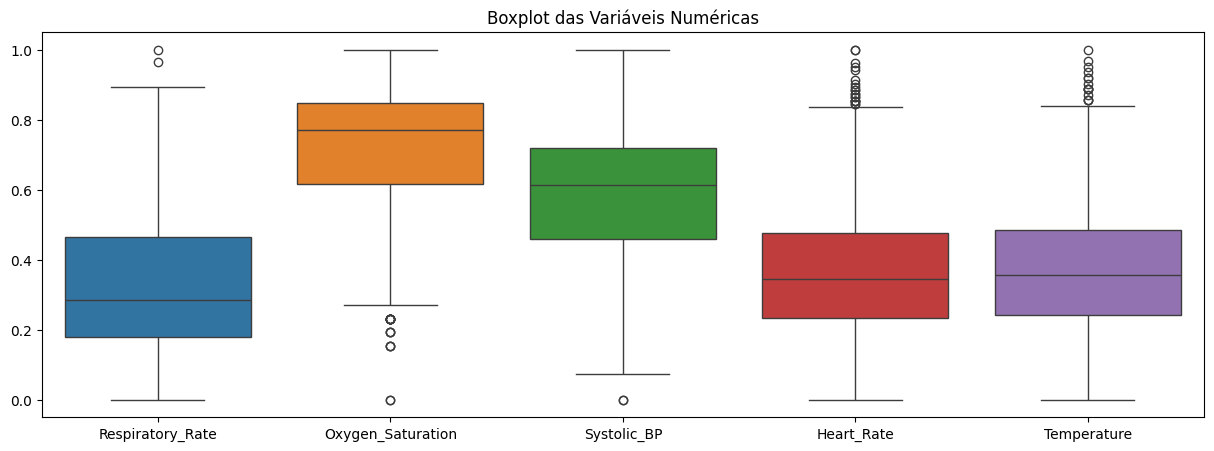

In [16]:
#Outliers
plt.figure(figsize=(15, 5))
sns.boxplot(data=df_health[numerical_cols])
plt.title('Boxplot das Variáveis Numéricas')
plt.show()

As as variáveis contêm valores atípicos (outliers), principalmente nas extremidades superiores, com exceção da saturação de oxigênio, que também tem valores atípicos inferiores. A presença de outliers elevados na Taxa Respiratória, Frequência Cardíaca e Temperatura pode indicar a existência de pacientes com condições clínicas anormais (taquipneia, taquicardia e febre), o que pode ser um sinal de alerta para a equipe médica.

In [17]:
#Método IQR
def remove_outliers_iqr(df_health, column):
    Q1 = df_health[column].quantile(0.25)
    Q3 = df_health[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_health[(df_health[column] >= lower_bound) & (df_health[column] <= upper_bound)]

df_no_outliers = remove_outliers_iqr(df_health, 'Heart_Rate')

print(f"Shape original: {df_health.shape}")
print(f"Shape após remoção de outliers: {df_no_outliers.shape}")

Shape original: (1000, 12)
Shape após remoção de outliers: (980, 12)


In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Relatório de Classificação para Random Forest:")
print(classification_report(y_test, y_pred_rf))

print("\n" + "="*50 + "\n")

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("Relatório de Classificação para XGBoost:")
print(classification_report(y_test, y_pred_xgb))

Relatório de Classificação para Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        56
           1       0.96      0.92      0.94        51
           2       0.91      0.98      0.94        61
           3       1.00      0.97      0.98        32

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



Relatório de Classificação para XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        56
           1       0.96      0.96      0.96        51
           2       0.94      0.97      0.95        61
           3       1.00      0.97      0.98        32

    accuracy                           0.96       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.96      0.97       200



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:12:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


C:\Users\Usuário\AppData\Local\Temp\ipykernel_12352\1377300874.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='F1-Score', data=df_comparison, palette='rocket')


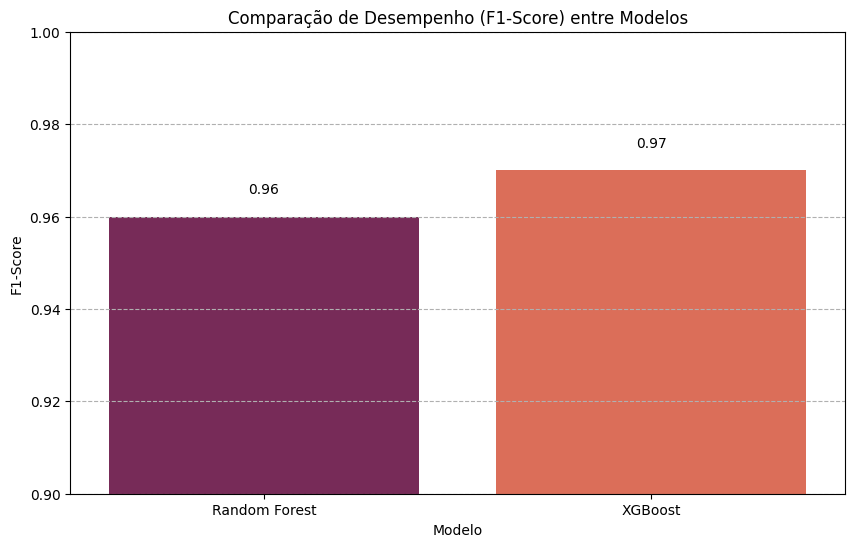

In [19]:
#Dados
data = {
    'Modelo': ['Random Forest', 'XGBoost'],
    'F1-Score': [0.96, 0.97],  
    'Precisão': [0.96, 0.97],
    'Recall': [0.96, 0.96],
    'Acurácia': [0.96, 0.96]
}
df_comparison = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='F1-Score', data=df_comparison, palette='rocket')

for index, row in df_comparison.iterrows():
    plt.text(index, row['F1-Score'] + 0.005, f'{row["F1-Score"]:.2f}', ha='center')

plt.ylim(0.90, 1.0)
plt.title('Comparação de Desempenho (F1-Score) entre Modelos')
plt.xlabel('Modelo')
plt.ylabel('F1-Score')
plt.grid(axis='y', linestyle='--')
plt.show()

O modelo XGBoost demonstrou ser o mais preciso na classificação, de acordo com a métrica F1-Score. Melhor equilíbrio entre a identificação correta de casos positivos e a minimização de falsos positivos e negativos.

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
#Definir a grade
param_grid = {
    'n_estimators': [100, 200],  
    'learning_rate': [0.05, 0.1, 0.2],  
    'max_depth': [3, 4, 5],  
    'subsample': [0.7, 0.8]  
}

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor F1-Score (média): {grid_search.best_score_:.2f}")

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print("Relatório de Classificação do modelo otimizado:")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:12:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}
Melhor F1-Score (média): 0.95
Relatório de Classificação do modelo otimizado:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        56
           1       0.96      0.92      0.94        51
           2       0.91      0.98      0.94        61
           3       1.00      0.97      0.98        32

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



C:\Users\Usuário\AppData\Local\Temp\ipykernel_12352\2157361098.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='rocket')


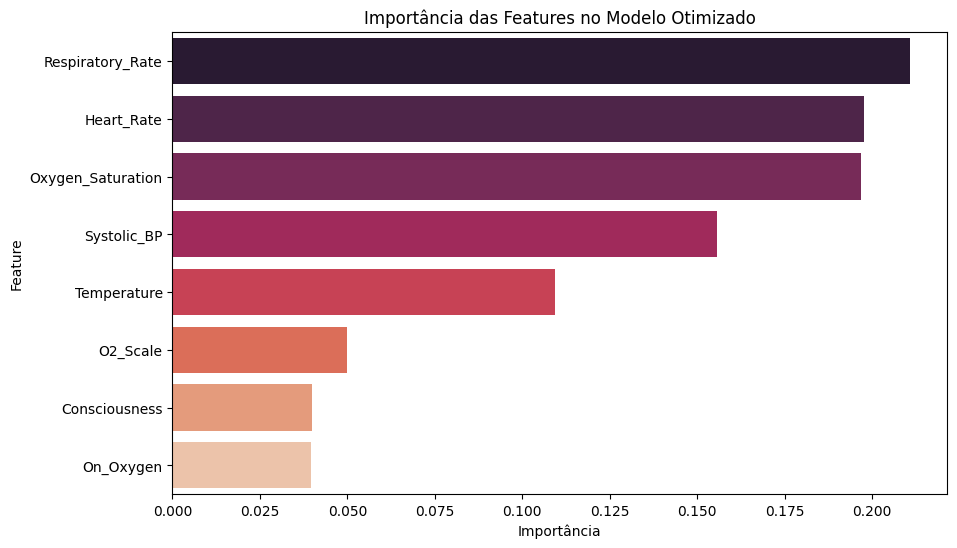

In [22]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='rocket')
plt.title('Importância das Features no Modelo Otimizado')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

Prioriza os sinais vitais clássicos (Taxa Respiratória, Frequência Cardíaca, Saturação de Oxigênio, Pressão Sanguínea e Temperatura) para fazer suas previsões. Essa hierarquia de importância está alinhada com o conhecimento clínico, onde esses parâmetros são fundamentais para avaliar o estado de um paciente.

In [23]:
#Defina o espaço 
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9]
}

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

print("Iniciando a busca em grade")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("---")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-Score médio (validação cruzada): {grid_search.best_score_:.4f}")

y_pred_tuned = best_model.predict(X_test)
print("Relatório de Classificação para o Modelo Otimizado:")
print(classification_report(y_test, y_pred_tuned))

Iniciando a busca em grade
Fitting 5 folds for each of 81 candidates, totalling 405 fits


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:12:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


---
Melhores parâmetros encontrados: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Melhor F1-Score médio (validação cruzada): 0.9501
Relatório de Classificação para o Modelo Otimizado:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        56
           1       0.96      0.92      0.94        51
           2       0.91      0.98      0.94        61
           3       1.00      0.97      0.98        32

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



C:\Users\Usuário\AppData\Local\Temp\ipykernel_12352\896403966.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='icefire')


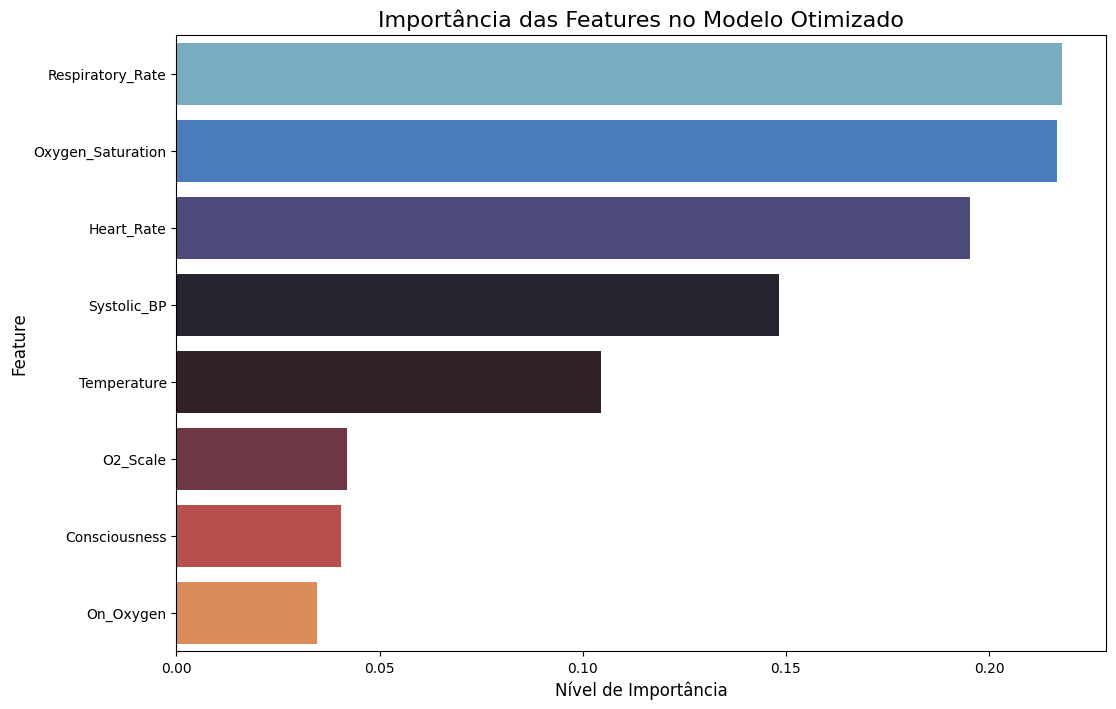

Análise de importância das features concluída.


In [24]:
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='icefire')

plt.title('Importância das Features no Modelo Otimizado', fontsize=16)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

print("Análise de importância das features concluída.")

Prioriza os sinais vitais clássicos (Taxa Respiratória, Saturação de Oxigênio, Frequência Cardíaca, Pressão Sanguínea e Temperatura) para fazer suas previsões. 

# Conclusão

A análise demonstra que é possível prever o risco à saúde com base em dados de pacientes. A importância de features não apenas valida o modelo, mas também fornece insights clínicos valiosos. Ela sugere que, entre os dados disponíveis, o ritmo cardíaco, a pressão arterial sistólica e a saturação de oxigênio são os indicadores mais relevantes para determinar o risco do paciente. 

# **Nathália Sorg**